# import libraries

In [16]:
import pandas as pd
from ax.service.ax_client import AxClient, ObjectiveProperties
import matplotlib.pyplot as plt
# from ax.modelbridge.factory import Models
from ax.modelbridge.registry import Models

from ax.modelbridge.generation_strategy import GenerationStep, GenerationStrategy   
import time


import sys
sys.path.append('../')
import helper_functions as hf

# generate recommendations

In [17]:
n = hf.get_iteration_number()

for i in range(3):
    print("Very Important: Please Confirm the Iteration Number is Iteration " + str(n))

Very Important: Please Confirm the Iteration Number is Iteration 3
Very Important: Please Confirm the Iteration Number is Iteration 3
Very Important: Please Confirm the Iteration Number is Iteration 3


In [18]:
optimizer_file_path = 'optimizer/optimizer_'
current_iteration = n


ax_client = AxClient.load_from_json_file("../iteration_" + str(current_iteration-1) + "/" + optimizer_file_path + str(current_iteration-1) + '_loaded.json')


In [19]:
from ax.service.ax_client import AxClient
from ax.modelbridge.factory import get_sobol
from ax.modelbridge.registry import Models

In [20]:
ax_client.experiment.trials['0']

KeyError: '0'

In [63]:
ax_client.experiment.trials

{0: Trial(experiment_name='drug_surfactant', index=0, status=TrialStatus.COMPLETED, arm=Arm(name='0_0', parameters={'Drug_MW': 0.206, 'Drug_LogP': 0.307, 'Drug_TPSA': 0.037, 's1': 47, 's2': 59, 's3': 49, 's4': 31, 's5': 96, 's6': 8, 's7': 9, 's8': 35, 'surfactant_conc': 85, 'drug_conc': 77})),
 1: Trial(experiment_name='drug_surfactant', index=1, status=TrialStatus.COMPLETED, arm=Arm(name='1_0', parameters={'Drug_MW': 0.206, 'Drug_LogP': 0.307, 'Drug_TPSA': 0.037, 's1': 95, 's2': 22, 's3': 76, 's4': 63, 's5': 42, 's6': 71, 's7': 55, 's8': 99, 'surfactant_conc': 35, 'drug_conc': 3})),
 2: Trial(experiment_name='drug_surfactant', index=2, status=TrialStatus.COMPLETED, arm=Arm(name='2_0', parameters={'Drug_MW': 0.206, 'Drug_LogP': 0.307, 'Drug_TPSA': 0.037, 's1': 52, 's2': 98, 's3': 4, 's4': 13, 's5': 22, 's6': 89, 's7': 28, 's8': 56, 'surfactant_conc': 18, 'drug_conc': 33})),
 3: Trial(experiment_name='drug_surfactant', index=3, status=TrialStatus.COMPLETED, arm=Arm(name='3_0', parameter

In [60]:
import pandas as pd

data = pd.DataFrame(data)
data

ValueError: If using all scalar values, you must pass an index

In [22]:
from ax.modelbridge.factory import get_saasbo
from ax.service.utils.report_utils import exp_to_df

# Get experiment and data
experiment = ax_client.experiment
df = exp_to_df(experiment)
data = ax_client._make_data(df)

# Build the SAASBO modelbridge
modelbridge = get_saasbo(experiment=experiment, data=data)

# Now you have access to the fitted BoTorch model
surrogate_model = modelbridge.model


ImportError: cannot import name 'get_saasbo' from 'ax.modelbridge.factory' (/Users/zeqing/opt/anaconda3/envs/sdlnano_plot/lib/python3.11/site-packages/ax/modelbridge/factory.py)

In [14]:
# Get the current modelbridge from the AxClient's generation strategy
modelbridge = ax_client.generation_strategy.model  # This is a ModelBridge object

# Access the underlying BoTorch model (the surrogate model)
surrogate_model = modelbridge.model  # Usually a BoTorch model, like SingleTaskGP


AttributeError: 'NoneType' object has no attribute 'model'

In [29]:
from ax.plot.parallel_coordinates import plot_parallel_coordinates

plot_parallel_coordinates(experiment, metric_name="your_metric_name")


ModuleNotFoundError: No module named 'ax.plot.parallel_coordinates'

In [56]:
from ax.modelbridge.factory import get_saasbo
from ax.service.utils.instantiation import ObjectiveProperties
from ax.service.utils.report_utils import exp_to_df

# 1. Get the experiment and data
experiment = ax_client.experiment
data = ax_client.get_trials_data_frame()

# 2. (Optional) Print metrics in your experiment
print(experiment.metrics)

# 3. Create the SAASBO model manually
modelbridge = get_saasbo(
    experiment=experiment,
    data=data,
    search_space=experiment.search_space,
)

# 4. Run cross-validation
from ax.modelbridge.cross_validation import cross_validate
cv_results = cross_validate(model=modelbridge)

# 5. Inspect the results
for r in cv_results:
    print(f"Arm: {r.arm_name}, Predicted: {r.mean:.4f}, Observed: {r.y:.4f}")


ImportError: cannot import name 'get_saasbo' from 'ax.modelbridge.factory' (/Users/zeqing/opt/anaconda3/envs/sdlnano_plot/lib/python3.11/site-packages/ax/modelbridge/factory.py)

In [13]:
print(ax_client.generation_strategy.model)


None


In [52]:
ax_client.experiment.trials

{0: Trial(experiment_name='drug_surfactant', index=0, status=TrialStatus.COMPLETED, arm=Arm(name='0_0', parameters={'Drug_MW': 0.206, 'Drug_LogP': 0.307, 'Drug_TPSA': 0.037, 's1': 47, 's2': 59, 's3': 49, 's4': 31, 's5': 96, 's6': 8, 's7': 9, 's8': 35, 'surfactant_conc': 85, 'drug_conc': 77})),
 1: Trial(experiment_name='drug_surfactant', index=1, status=TrialStatus.COMPLETED, arm=Arm(name='1_0', parameters={'Drug_MW': 0.206, 'Drug_LogP': 0.307, 'Drug_TPSA': 0.037, 's1': 95, 's2': 22, 's3': 76, 's4': 63, 's5': 42, 's6': 71, 's7': 55, 's8': 99, 'surfactant_conc': 35, 'drug_conc': 3})),
 2: Trial(experiment_name='drug_surfactant', index=2, status=TrialStatus.COMPLETED, arm=Arm(name='2_0', parameters={'Drug_MW': 0.206, 'Drug_LogP': 0.307, 'Drug_TPSA': 0.037, 's1': 52, 's2': 98, 's3': 4, 's4': 13, 's5': 22, 's6': 89, 's7': 28, 's8': 56, 'surfactant_conc': 18, 'drug_conc': 33})),
 3: Trial(experiment_name='drug_surfactant', index=3, status=TrialStatus.COMPLETED, arm=Arm(name='3_0', parameter

In [50]:
from ax.modelbridge.cross_validation import cross_validate

# Step 1: Get the modelbridge from AxClient
model = ax_client.generation_strategy.model  # This is the modelbridge used

# Step 2: Run cross-validation
cv_results = cross_validate(model=model)

# Step 3: Explore results
for result in cv_results:
    print(f"Arm: {result.arm_name}, Predicted: {result.mean:.4f}, Observed: {result.y:.4f}")


AttributeError: 'NoneType' object has no attribute 'get_training_data'

In [66]:
ax_client.compute_analyses()

[ERROR 06-20 12:17:08] ax.analysis.analysis: Failed to compute ParallelCoordinatesPlot: Cannot infer metric to plot from MultiObjective, please specify a metric


In [80]:
df = ax_client.get_trials_data_frame()

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

para_cols = ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 'surfactant_conc', 'drug_conc']
obj_cols = ['complexity', 'micelle_drug_conc', 'surfactant_conc']

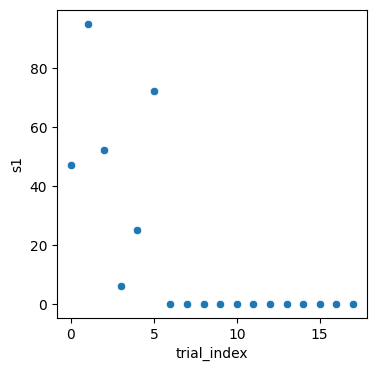

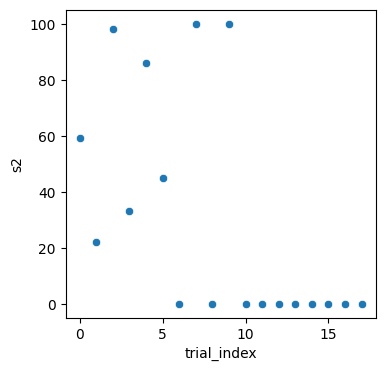

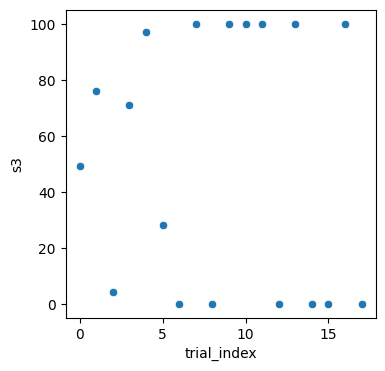

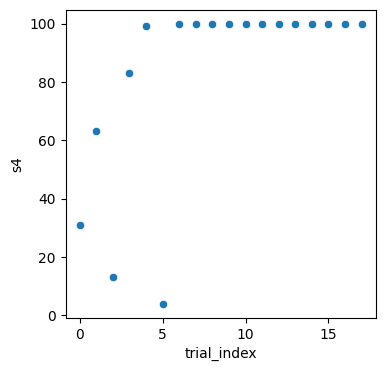

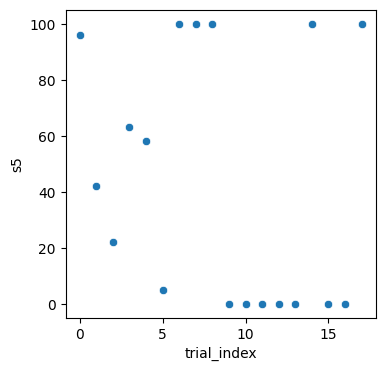

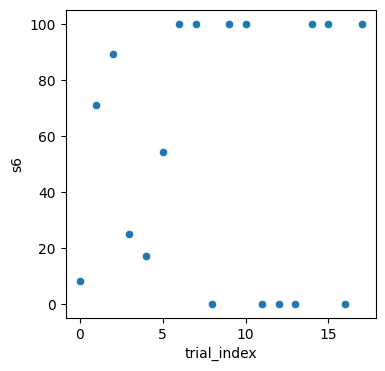

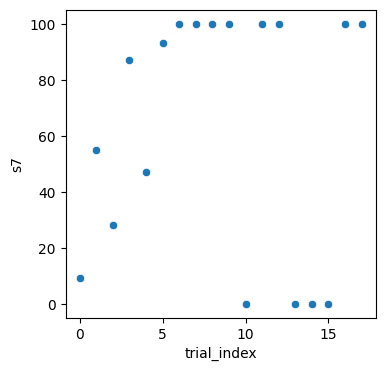

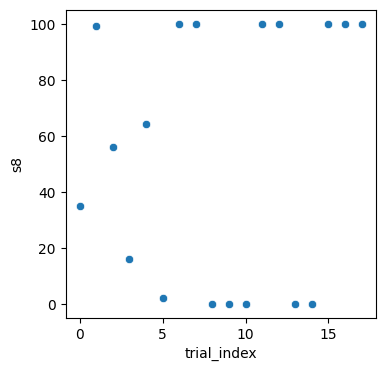

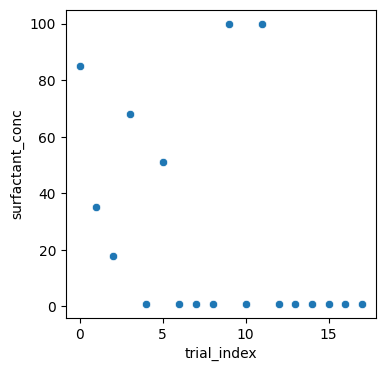

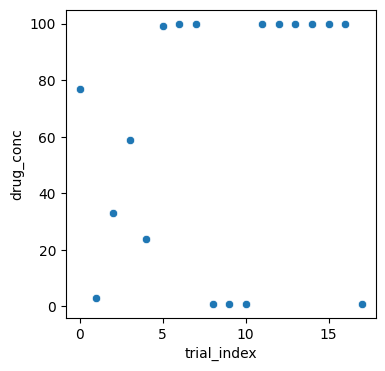

In [83]:
for col in para_cols:

    plt.figure(figsize=(4, 4))
    sns.scatterplot(data=df, x='trial_index', y=col)

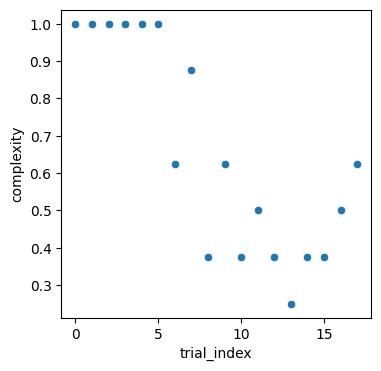

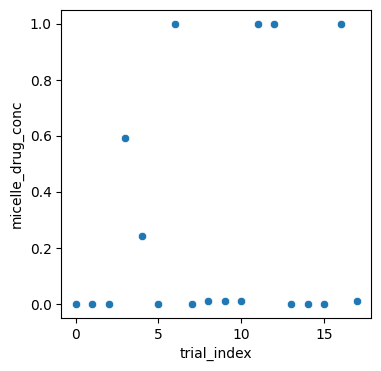

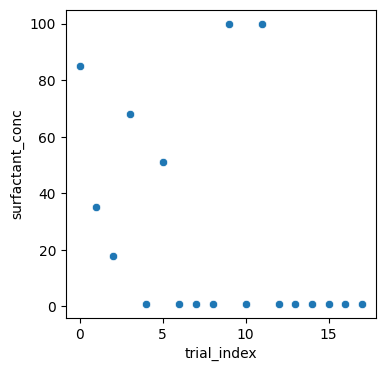

In [84]:
for col in obj_cols:

    plt.figure(figsize=(4, 4))
    sns.scatterplot(data=df, x='trial_index', y=col)

In [ ]:
for col in ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8',]:
    if col in df.columns:
        df[col] = df[col].astype(float)

In [71]:
from ax.service.utils.report_utils import exp_to_df

df = exp_to_df(ax_client.experiment)
df

,trial_index,arm_name,trial_status,generation_method,complexity,micelle_drug_conc,surfactant_conc_x,Drug_MW,Drug_LogP,Drug_TPSA,s1,s2,s3,s4,s5,s6,s7,s8,surfactant_conc_y,drug_conc
0,0,0_0,COMPLETED,Sobol,1.000,0.00,0.85,0.206,0.307,0.037,47,59,49,31,96,8,9,35,85,77
1,1,1_0,COMPLETED,Sobol,1.000,0.00,0.35,0.206,0.307,0.037,95,22,76,63,42,71,55,99,35,3
2,2,2_0,COMPLETED,Sobol,1.000,0.00,0.18,0.206,0.307,0.037,52,98,4,13,22,89,28,56,18,33
3,3,3_0,COMPLETED,Sobol,1.000,0.59,0.68,0.206,0.307,0.037,6,33,71,83,63,25,87,16,68,59
4,4,4_0,COMPLETED,Sobol,1.000,0.24,0.01,0.206,0.307,0.037,25,86,97,99,58,17,47,64,1,24
5,5,5_0,COMPLETED,Sobol,1.000,0.00,0.51,0.206,0.307,0.037,72,45,28,4,5,54,93,2,51,99
6,6,6_0,COMPLETED,SAASBO,0.625,1.00,0.01,0.206,0.307,0.037,0,0,0,100,100,100,100,100,1,100
7,7,7_0,COMPLETED,SAASBO,0.875,0.00,0.01,0.206,0.307,0.037,0,100,100,100,100,100,100,100,1,100
8,8,8_0,COMPLETED,SAASBO,0.375,0.01,0.01,0.206,0.307,0.037,0,0,0,100,100,0,100,0,1,1
9,9,9_0,COMPLETED,SAASBO,0.625,0.01,1.00,0.206,0.307,0.037,0,100,100,100,0,100,100,0,100,1


In [69]:
ax_client.experiment.fetch_data()



ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.

In [13]:
surrogate_model = modelbridge.model


NameError: name 'modelbridge' is not defined

In [15]:
time_start = time.time()


df_design, ax_client = hf.run_optimizer(current_iteration=n, drug = "IBP", bopt = 1, n_trials=6)

time_end = time.time()
time_duration = round((time_end - time_start)/60,2)

print("Time taken for optimization: " + str(time_duration) + " mins")
print("Time taken for optimization: " + str(time_duration * 60) + " seconds")

**************************************************************************************************************

Generating Bayesian Optimization trialsfor
Drug name:  Ibuprofen IBP  | Iteration:  3

**************************************************************************************************************


KeyboardInterrupt: 

# process results

In [4]:
ax_client = hf.load_design_optimizer(n)
ax_client.experiment.trials

[INFO 06-19 15:05:22] ax.service.ax_client: Starting optimization with verbose logging. To disable logging, set the `verbose_logging` argument to `False`. Note that float values in the logs are rounded to 6 decimal points.


{0: Trial(experiment_name='drug_surfactant', index=0, status=TrialStatus.COMPLETED, arm=Arm(name='0_0', parameters={'Drug_MW': 0.206, 'Drug_LogP': 0.307, 'Drug_TPSA': 0.037, 's1': 47, 's2': 59, 's3': 49, 's4': 31, 's5': 96, 's6': 8, 's7': 9, 's8': 35, 'surfactant_conc': 85, 'drug_conc': 77})),
 1: Trial(experiment_name='drug_surfactant', index=1, status=TrialStatus.COMPLETED, arm=Arm(name='1_0', parameters={'Drug_MW': 0.206, 'Drug_LogP': 0.307, 'Drug_TPSA': 0.037, 's1': 95, 's2': 22, 's3': 76, 's4': 63, 's5': 42, 's6': 71, 's7': 55, 's8': 99, 'surfactant_conc': 35, 'drug_conc': 3})),
 2: Trial(experiment_name='drug_surfactant', index=2, status=TrialStatus.COMPLETED, arm=Arm(name='2_0', parameters={'Drug_MW': 0.206, 'Drug_LogP': 0.307, 'Drug_TPSA': 0.037, 's1': 52, 's2': 98, 's3': 4, 's4': 13, 's5': 22, 's6': 89, 's7': 28, 's8': 56, 'surfactant_conc': 18, 'drug_conc': 33})),
 3: Trial(experiment_name='drug_surfactant', index=3, status=TrialStatus.COMPLETED, arm=Arm(name='3_0', parameter

In [5]:
df_conc, df_vol = hf.design_to_conc_to_vol (n)

In [6]:
plate_well = input("Enter the plate well starting well (e.g., F1): ")
deepplate_well = input("Enter the deep plate well starting well (e.g., F1): ")


print("Please confirm the following information:")
print("Wellplate will start at: " + plate_well)
print("Deep plate will start at: " + deepplate_well)

print()
print("*******************************************************")
print("Continue if correct, or rerun this cell if incorrect.")
print("*******************************************************")

Please confirm the following information:
Wellplate will start at: B1
Deep plate will start at: D1

*******************************************************
Continue if correct, or rerun this cell if incorrect.
*******************************************************


In [7]:

hf.generate_protocol(df_vol=df_vol, iteration=n, plate_well=plate_well, deepplate_well=deepplate_well)

✅ Successfully wrote to: protocol/otflex_3.py


In [6]:
df_absorbance = hf.process_absorbance(iteration=n, threshold=0.1)
df_absorbance

,trial_index,success
0,0,0


In [8]:
results = hf.build_results(n, df_conc, df_absorbance)
results

,trial_index,s1,s2,s3,s4,s5,s6,s7,s8,s9,surfactant_conc,drug_conc,success,micelle_drug_conc,complexity
0,6,0,0,100,100,52,63,100,100,76,0.5,18.5,0,0.0,7


In [17]:
norm_results = hf.normalize_data(results, 'normalize')

In [18]:
norm_results

,trial_index,s1,s2,s3,s4,s5,s6,s7,s8,s9,surfactant_conc,drug_conc,success,micelle_drug_conc,complexity
0,6,0,0,100,100,52,63,100,100,76,0.01,18.5,0,0.0,0.777778


# load the results to the optimizer

In [19]:
ax_client = hf.load_data_to_optimizer(iteration = n, norm_results = norm_results)
ax_client

[INFO 06-06 11:57:51] ax.service.ax_client: Starting optimization with verbose logging. To disable logging, set the `verbose_logging` argument to `False`. Note that float values in the logs are rounded to 6 decimal points.
[INFO 06-06 11:57:51] ax.service.ax_client: Completed trial 6 with data: {'micelle_drug_conc': (0.0, None), 'surfactant_conc': (0.01, None), 'complexity': (0.777778, None)}.
[INFO 06-06 11:57:51] ax.service.ax_client: Saved JSON-serialized state of optimization to `optimizer/optimizer_1_loaded.json`.


AxClient(experiment=Experiment(drug_surfactant))